# TASK:2

1) Determine whether the LinearRegressionNN model is suitable for the dataset binary_classification_moons.csv.

2) Determine whether the following model ModelV0 is suitable for the same dataset. Justify your answer by explaining why the model is or is not appropriate.

3) Modify the model by increasing the number of layers and/or hidden units. An example is provided in Lab-5.1-NN.ipynb. Evaluate the suitability of the resulting model architecture(s) for the binary_classification_moons.csv dataset and justify your conclusions.

In [1]:

import torch
import torch.nn as nn
     

import pandas as pd
     

df = pd.read_csv("binary_classification_moons.csv")
     

df.head()

,X1,X2,label
0,-0.009332,0.390981,1
1,0.954574,-0.473756,1
2,0.918526,-0.425196,1
3,0.412768,-0.376385,1
4,-0.845320,0.528799,0


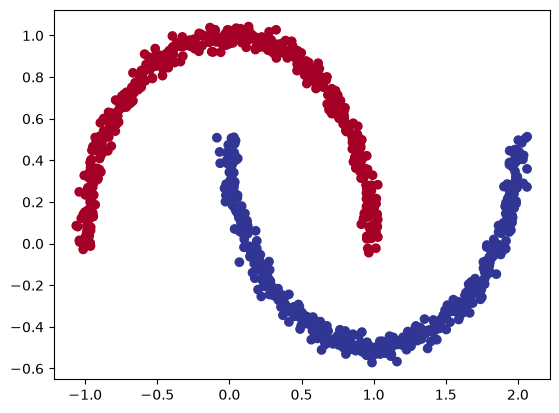

In [2]:
# Visualize with a plot
import matplotlib.pyplot as plt
plt.scatter(
            x=df.X1,
            y=df.X2,
            c=df.label,
            cmap=plt.cm.RdYlBu
            );
     

In [3]:
X = df[['X1', 'X2']].values
y = df['label'].values
     

print(f"First 5 X features:\n{X[:5]}")
print(f"\nFirst 5 y labels:\n{y[:5]}")
     

First 5 X features:
[[-0.00933187  0.39098105]
 [ 0.95457387 -0.47375583]
 [ 0.9185256  -0.42519648]
 [ 0.41276802 -0.37638459]
 [-0.84532016  0.52879908]]

First 5 y labels:
[1 1 1 1 0]


In [4]:
X.shape, y.shape
     

((1000, 2), (1000,))

In [5]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# View the first five samples
X[:5], y[:5]

C:\Users\bidhi\AppData\Local\Temp\ipykernel_10624\2242702081.py:2: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  y = torch.from_numpy(y).type(torch.float)


(tensor([[-0.0093,  0.3910],
         [ 0.9546, -0.4738],
         [ 0.9185, -0.4252],
         [ 0.4128, -0.3764],
         [-0.8453,  0.5288]]),
 tensor([1., 1., 1., 1., 0.]))

In [6]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2, # 20% test, 80% train
                                                    random_state=42,
                                                    stratify=y) # make the random split reproducible

len(X_train), len(X_test), len(y_train), len(y_test)
     

(800, 200, 800, 200)

In [7]:
# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device
     

'cpu'

In [8]:
# 1. Construct a model class that subclasses nn.Module
class ModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        # 2. Create 2 nn.Linear layers capable of handling X and y input and output shapes
        self.layer_1 = nn.Linear(in_features=2, out_features=5) # takes in 2 features (X), produces 5 features
        self.layer_2 = nn.Linear(in_features=5, out_features=1) # takes in 5 features, produces 1 feature (y)

    # 3. Define a forward method containing the forward pass computation
    def forward(self, x):
        # Return the output of layer_2, a single feature, the same shape as y
        return self.layer_2(self.layer_1(x)) # computation goes through layer_1 first then the output of layer_1 goes through layer_2

# 4. Create an instance of the model and send it to target device
model_0 = ModelV0().to(device)
model_0

ModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [9]:
model = model_0

In [10]:

# Make predictions with the model
untrained_preds = model(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(y_test)}, Shape: {y_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200])

First 10 predictions:
tensor([[-0.1255],
        [-0.2873],
        [-0.2833],
        [-0.2979],
        [ 0.0228],
        [-0.0975],
        [-0.0378],
        [-0.0252],
        [-0.1997],
        [-0.2087]], grad_fn=<SliceBackward0>)

First 10 test labels:
tensor([1., 0., 0., 0., 1., 1., 1., 1., 0., 0.])


In [11]:
# Create a loss function
# loss_fn = nn.BCELoss() # BCELoss = no sigmoid built-in
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=model.parameters(),
                            lr=0.1)
     

# View the frist 5 outputs of the forward pass on the test data
y_logits = model(X_test.to(device))[:5]
y_logits

tensor([[-0.1255],
        [-0.2873],
        [-0.2833],
        [-0.2979],
        [ 0.0228]], grad_fn=<SliceBackward0>)

In [12]:

# Use sigmoid on model logits
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4687],
        [0.4287],
        [0.4297],
        [0.4261],
        [0.5057]], grad_fn=<SigmoidBackward0>)

In [13]:
# Find the predicted labels (round the prediction probabilities)
y_preds = torch.round(y_pred_probs)

# In full
y_pred_labels = torch.round(torch.sigmoid(model(X_test.to(device))[:5]))

# Check for equality
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# Get rid of extra dimension
y_preds.squeeze()

tensor([True, True, True, True, True])


tensor([0., 0., 0., 0., 1.], grad_fn=<SqueezeBackward0>)

In [14]:

y_test[:5]
     

tensor([1., 0., 0., 0., 1.])

In [15]:
torch.manual_seed(42)

# Set the number of epochs
epochs = 100

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

In [16]:
torch.manual_seed(42)

# Set the number of epochs
epochs = 100

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

In [17]:
torch.manual_seed(42)

# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

# Set the number of epochs
epochs = 100

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Build training and evaluation loop
train_losses = []
acc_list = []
test_losses = []
test_acc = []

for epoch in range(epochs):
    ### Training
    model.train()

    # 1. Forward pass
    y_logits = model(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # logits -> prediction probabilities -> prediction labels

    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        # 2. Calculate test loss and accuracy
        test_loss = loss_fn(test_logits, y_test)
        test_acc_val = accuracy_fn(y_true=y_test, y_pred=test_pred)

    # Print out what's happening
    if epoch % 10 == 0:
        train_losses.append(loss.item())
        acc_list.append(acc)
        test_losses.append(test_loss.item())
        test_acc.append(test_acc_val)
        print(f"Epoch: {epoch} | Train Loss: {loss:.5f} | Train Acc: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc_val:.2f}%")

print("\nTraining complete!")


Epoch: 0 | Train Loss: 0.64134 | Train Acc: 80.25% | Test Loss: 0.62570 | Test Acc: 87.50%
Epoch: 10 | Train Loss: 0.55458 | Train Acc: 79.38% | Test Loss: 0.54015 | Test Acc: 79.50%
Epoch: 20 | Train Loss: 0.50147 | Train Acc: 79.00% | Test Loss: 0.48454 | Test Acc: 79.00%
Epoch: 30 | Train Loss: 0.45965 | Train Acc: 78.50% | Test Loss: 0.44003 | Test Acc: 80.00%
Epoch: 40 | Train Loss: 0.42592 | Train Acc: 79.00% | Test Loss: 0.40378 | Test Acc: 81.50%
Epoch: 50 | Train Loss: 0.39912 | Train Acc: 80.00% | Test Loss: 0.37460 | Test Acc: 82.50%
Epoch: 60 | Train Loss: 0.37789 | Train Acc: 81.00% | Test Loss: 0.35114 | Test Acc: 83.50%
Epoch: 70 | Train Loss: 0.36088 | Train Acc: 81.00% | Test Loss: 0.33208 | Test Acc: 84.50%
Epoch: 80 | Train Loss: 0.34694 | Train Acc: 81.88% | Test Loss: 0.31630 | Test Acc: 85.50%
Epoch: 90 | Train Loss: 0.33524 | Train Acc: 82.12% | Test Loss: 0.30299 | Test Acc: 86.00%

Training complete!


In [18]:
torch.manual_seed(42)

# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

# Set the number of epochs
epochs = 100

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Build training and evaluation loop
train_losses = []
acc_list = []
test_losses = []
test_acc = []

for epoch in range(epochs):
    ### Training
    model.train()

    # 1. Forward pass
    y_logits = model(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # logits -> prediction probabilities -> prediction labels

    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        # 2. Calculate test loss and accuracy
        test_loss = loss_fn(test_logits, y_test)
        test_acc_val = accuracy_fn(y_true=y_test, y_pred=test_pred)

    # Print out what's happening
    if epoch % 10 == 0:
        train_losses.append(loss.item())
        acc_list.append(acc)
        test_losses.append(test_loss.item())
        test_acc.append(test_acc_val)
        print(f"Epoch: {epoch} | Train Loss: {loss:.5f} | Train Acc: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc_val:.2f}%")

print("\nTraining complete!")


Epoch: 0 | Train Loss: 0.32521 | Train Acc: 82.75% | Test Loss: 0.29155 | Test Acc: 86.00%
Epoch: 10 | Train Loss: 0.31646 | Train Acc: 83.50% | Test Loss: 0.28160 | Test Acc: 86.00%
Epoch: 20 | Train Loss: 0.30874 | Train Acc: 84.25% | Test Loss: 0.27284 | Test Acc: 86.00%
Epoch: 30 | Train Loss: 0.30186 | Train Acc: 84.50% | Test Loss: 0.26508 | Test Acc: 86.00%
Epoch: 40 | Train Loss: 0.29571 | Train Acc: 84.62% | Test Loss: 0.25818 | Test Acc: 87.00%
Epoch: 50 | Train Loss: 0.29021 | Train Acc: 85.12% | Test Loss: 0.25203 | Test Acc: 87.00%
Epoch: 60 | Train Loss: 0.28529 | Train Acc: 85.12% | Test Loss: 0.24654 | Test Acc: 88.00%
Epoch: 70 | Train Loss: 0.28090 | Train Acc: 85.62% | Test Loss: 0.24165 | Test Acc: 88.00%
Epoch: 80 | Train Loss: 0.27700 | Train Acc: 86.00% | Test Loss: 0.23729 | Test Acc: 88.50%
Epoch: 90 | Train Loss: 0.27353 | Train Acc: 86.12% | Test Loss: 0.23341 | Test Acc: 89.50%

Training complete!


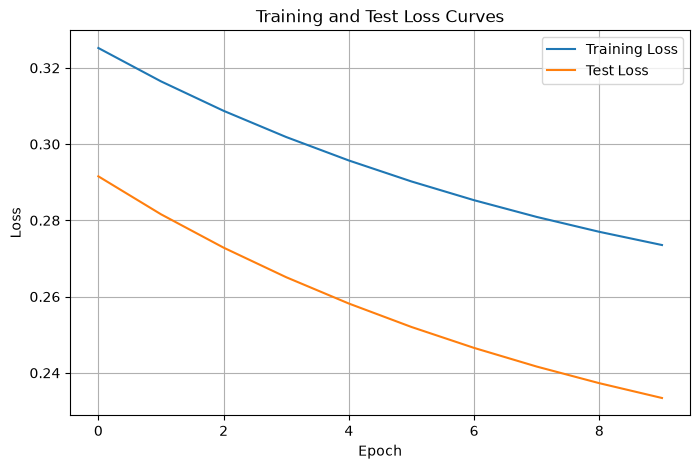

In [19]:
import matplotlib.pyplot as plt

def plot_loss_curves(train_losses, test_losses):
    """
    Plots training and testing loss curves.

    Args:
        train_losses (list): Loss values from training
        test_losses (list): Loss values from testing
    """
    epochs = range(len(train_losses))

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_losses, label="Training Loss")
    plt.plot(epochs, test_losses, label="Test Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Test Loss Curves")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_loss_curves(train_losses, test_losses)

In [20]:

class ModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU() # Add ReLU activation function

    def forward(self, x): # note: always make sure forward is spelt correctly!
        # Creating a model like this is the same as below, though below
        # generally benefits from speedups where possible.
        # z = self.layer_1(x)
        # z = self.layer_2(z)
        # z = self.layer_3(z)
        # return z
        # Now with ReLU activations in between the layers
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_1 = ModelV1().to(device)
model_1

ModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [21]:
model = model_1
epochs = 2000

# Create a loss function
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=model.parameters(),
                            lr=0.1)

Epoch: 0 | Train Loss: 0.00401 | Train Acc: 100.00% | Test Loss: 0.00378 | Test Acc: 100.00%
Epoch: 100 | Train Loss: 0.00369 | Train Acc: 100.00% | Test Loss: 0.00350 | Test Acc: 100.00%
Epoch: 200 | Train Loss: 0.00342 | Train Acc: 100.00% | Test Loss: 0.00325 | Test Acc: 100.00%
Epoch: 300 | Train Loss: 0.00318 | Train Acc: 100.00% | Test Loss: 0.00304 | Test Acc: 100.00%
Epoch: 400 | Train Loss: 0.00298 | Train Acc: 100.00% | Test Loss: 0.00285 | Test Acc: 100.00%
Epoch: 500 | Train Loss: 0.00279 | Train Acc: 100.00% | Test Loss: 0.00268 | Test Acc: 100.00%
Epoch: 600 | Train Loss: 0.00262 | Train Acc: 100.00% | Test Loss: 0.00253 | Test Acc: 100.00%
Epoch: 700 | Train Loss: 0.00247 | Train Acc: 100.00% | Test Loss: 0.00239 | Test Acc: 100.00%
Epoch: 800 | Train Loss: 0.00234 | Train Acc: 100.00% | Test Loss: 0.00227 | Test Acc: 100.00%
Epoch: 900 | Train Loss: 0.00222 | Train Acc: 100.00% | Test Loss: 0.00215 | Test Acc: 100.00%
Epoch: 1000 | Train Loss: 0.00211 | Train Acc: 100.0

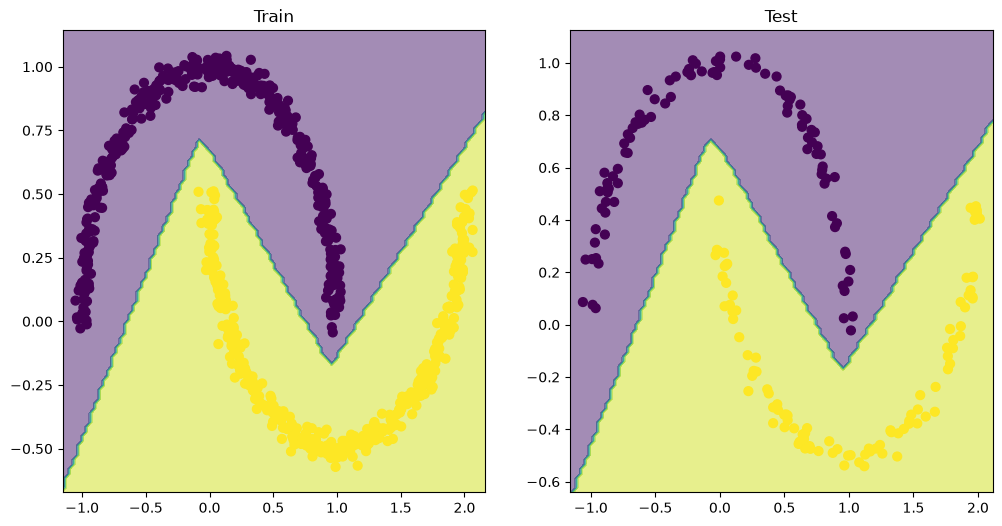

In [ ]:
torch.manual_seed(42)

# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

# Put data to target device (if not already done, important for fresh runs)
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Build training and evaluation loop
train_losses = []
acc_list = []
test_losses = []
test_acc = []

for epoch in range(epochs):
    ### Training
    model.train()

    # 1. Forward pass
    y_logits = model(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # logits -> prediction probabilities -> prediction labels

    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        # 2. Calculate test loss and accuracy
        test_loss = loss_fn(test_logits, y_test)
        test_acc_val = accuracy_fn(y_true=y_test, y_pred=test_pred)

    # Print out what's happening
    if epoch % 100 == 0 or epoch == epochs - 1:
        train_losses.append(loss.item())
        acc_list.append(acc)
        test_losses.append(test_loss.item())
        test_acc.append(test_acc_val)
        print(f"Epoch: {epoch} | Train Loss: {loss:.5f} | Train Acc: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc_val:.2f}%")

print("\nTraining complete!")

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

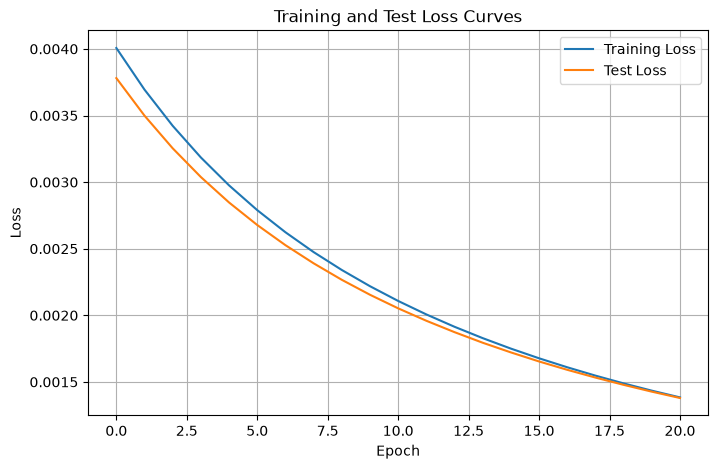

In [26]:
plot_loss_curves(train_losses, test_losses)
     

### ModelV1 is highly suitable for the binary_classification_moons dataset. The additional hidden layer and ReLU activation functions allow the network to learn non-linear decision boundaries. The model achieved 100% training and testing accuracy with very low loss values, indicating that it successfully captured the complex moon-shaped structure of the data. The decision boundary closely follows the shape of the classes, making it significantly more effective than ModelV0.
